   student_id  weekly_self_study_hours  attendance_percentage  \
0      987232                      3.9                   96.7   
1       79955                     17.1                   73.9   
2      567131                      8.7                   98.7   
3      500892                     15.0                   92.7   
4       55400                      0.9                   87.0   

   class_participation  total_score grade  
0                  6.7         53.9     D  
1                  5.4         77.3     B  
2                  3.0         75.0     B  
3                  0.1         85.7     A  
4                  5.4         30.8     F  

Shape: (50000, 6)

Missing Values:
 student_id                 0
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0
dtype: int64

Class Distribution:
pass
1    36061
0    13939
Name: count, dtype: int64
Pass Rate: 72.1%


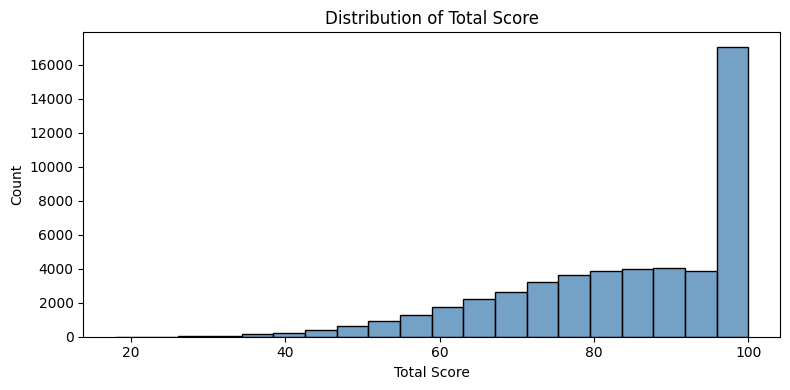

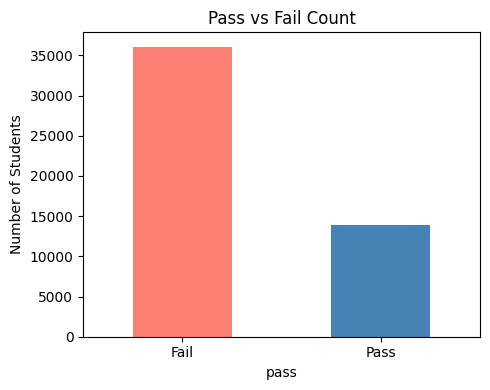


Features used: ['weekly_self_study_hours', 'attendance_percentage', 'class_participation']
Number of features: 3

Training samples : 40000
Testing samples  : 10000

Logistic Regression
Accuracy  : 0.8296
Precision : 0.8542
Recall    : 0.9212
F1 Score  : 0.8865
Confusion Matrix:
[[1644 1135]
 [ 569 6652]]

Decision Tree
Accuracy  : 0.9292
Precision : 0.9514
Recall    : 0.9506
F1 Score  : 0.9510
Confusion Matrix:
[[2428  351]
 [ 357 6864]]

KNN (k=5)
Accuracy  : 0.9382
Precision : 0.9471
Recall    : 0.9686
F1 Score  : 0.9577
Confusion Matrix:
[[2388  391]
 [ 227 6994]]

Naive Bayes
Accuracy  : 0.8756
Precision : 0.8710
Recall    : 0.9716
F1 Score  : 0.9186
Confusion Matrix:
[[1740 1039]
 [ 205 7016]]

Random Forest
Accuracy  : 0.9453
Precision : 0.9517
Recall    : 0.9737
F1 Score  : 0.9626
Confusion Matrix:
[[2422  357]
 [ 190 7031]]

MODEL COMPARISON TABLE
                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Random Forest

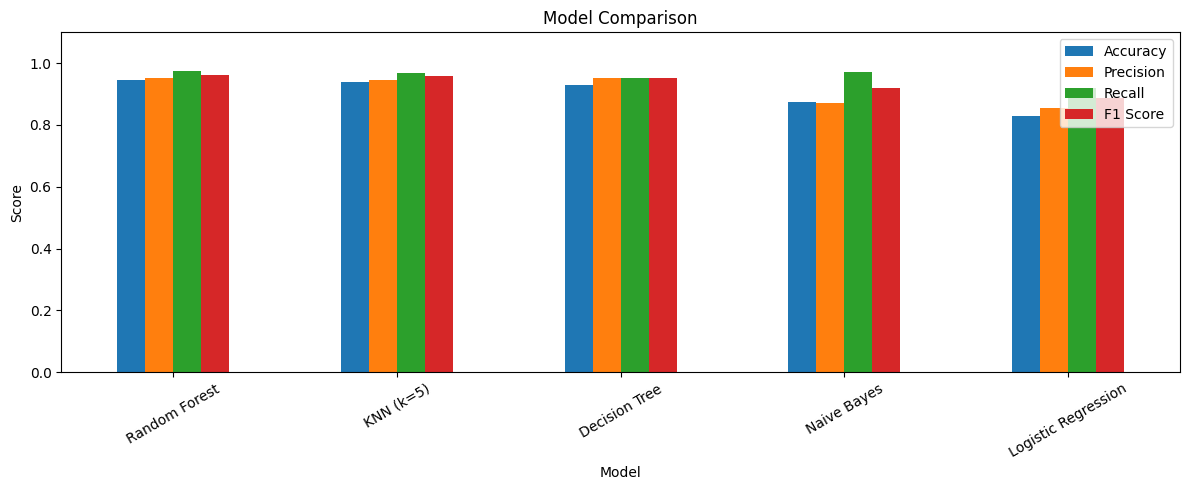


Best Model based on F1 Score: Random Forest

Top 3 Important Features:
attendance_percentage      0.591750
class_participation        0.249639
weekly_self_study_hours    0.158611
dtype: float64


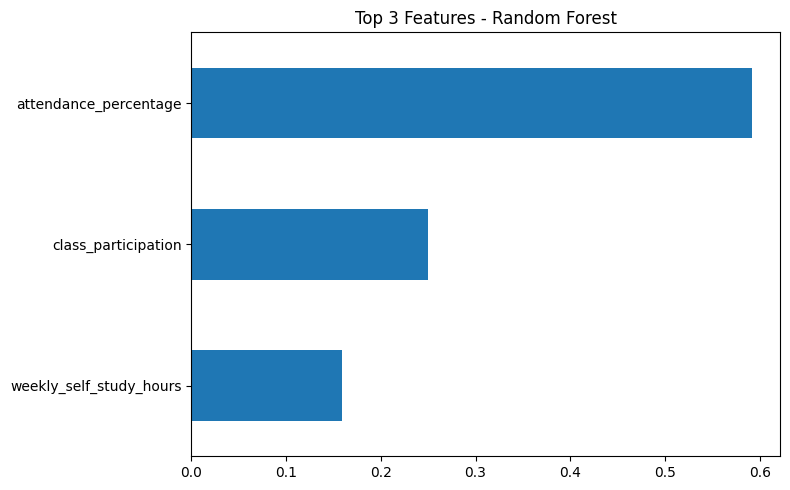


Final Model Performance (Top 3 Features Only):

Final Random Forest
Accuracy  : 0.9465
Precision : 0.9547
Recall    : 0.9724
F1 Score  : 0.9635
Confusion Matrix:
[[2406  335]
 [ 200 7059]]

Model saved as final_model.pkl


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB


# ==============================
# LOAD DATA
# ==============================

df = pd.read_csv("D:\Practice\AI_Traning\Project\student_performance.csv")  # update path if needed
df = df.sample(n=50000, random_state=42).reset_index(drop=True)
print(df.head())
print("\nShape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())


# ==============================
# CREATE TARGET VARIABLE
# ==============================

# Pass if total_score >= 50
df['pass'] = df.apply(
    lambda row: 1 if row['total_score'] >= 60 
                  and row['attendance_percentage'] >= 75 
                  and row['class_participation'] >= 3 
                else 0, 
    axis=1
)

print("\nClass Distribution:")
print(df['pass'].value_counts())
print(f"Pass Rate: {df['pass'].mean() * 100:.1f}%")


# ==============================
# VISUALIZATIONS
# ==============================

plt.figure(figsize=(8, 4))
sns.histplot(df['total_score'], bins=20, color='steelblue')
plt.title("Distribution of Total Score")
plt.xlabel("Total Score")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("plot_score_distribution.png")
plt.show()


plt.figure(figsize=(5, 4))
df['pass'].value_counts().plot(kind='bar', color=['salmon', 'steelblue'])
plt.xticks([0, 1], ['Fail', 'Pass'], rotation=0)
plt.title("Pass vs Fail Count")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.savefig("plot_pass_fail_count.png")
plt.show()


# ==============================
# FEATURES & TARGET
# ==============================

# Drop student_id, total_score (used to derive target), and grade (label, not a feature)
X = df.drop(['student_id', 'total_score', 'grade', 'pass'], axis=1)
y = df['pass']

print("\nFeatures used:", list(X.columns))
print("Number of features:", X.shape[1])


# ==============================
# TRAIN TEST SPLIT
# ==============================

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=51
)

print(f"\nTraining samples : {x_train.shape[0]}")
print(f"Testing samples  : {x_test.shape[0]}")


# ==============================
# SCALING (for LR & KNN)
# ==============================

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


# ==============================
# EVALUATION FUNCTION
# ==============================

def evaluate_model(name, y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    pr  = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1  = f1_score(y_test, y_pred, zero_division=0)
    cm  = confusion_matrix(y_test, y_pred)

    print(f"\n{'='*40}")
    print(f"{name}")
    print(f"{'='*40}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {pr:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"Confusion Matrix:\n{cm}")

    return {"Model": name, "Accuracy": acc, "Precision": pr, "Recall": rec, "F1 Score": f1}


# ==============================
# TRAIN MODELS
# ==============================

results = []

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train_scaled, y_train)
results.append(evaluate_model("Logistic Regression", y_test, lr.predict(x_test_scaled)))

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)
results.append(evaluate_model("Decision Tree", y_test, dt.predict(x_test)))

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_scaled, y_train)
results.append(evaluate_model("KNN (k=5)", y_test, knn.predict(x_test_scaled)))

# Naive Bayes
nb = GaussianNB()
nb.fit(x_train, y_train)
results.append(evaluate_model("Naive Bayes", y_test, nb.predict(x_test)))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
results.append(evaluate_model("Random Forest", y_test, rf.predict(x_test)))


# ==============================
# COMPARISON TABLE
# ==============================

print("\nMODEL COMPARISON TABLE")
results_df = pd.DataFrame(results).set_index("Model")
results_df = results_df.sort_values("F1 Score", ascending=False)
print(results_df.round(4))

# Plot comparison
results_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(
    kind='bar', figsize=(12, 5)
)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("plot_model_comparison.png")
plt.show()


# ==============================
# BEST MODEL
# ==============================

best_model_name = results_df.index[0]
print(f"\nBest Model based on F1 Score: {best_model_name}")


# ==============================
# FEATURE IMPORTANCE (Random Forest)
# ==============================

importances = pd.Series(rf.feature_importances_, index=X.columns)

# Use all features if fewer than 6, otherwise top 6
n_top = min(6, len(importances))
top_features = importances.sort_values(ascending=False).head(n_top)

print(f"\nTop {n_top} Important Features:")
print(top_features)

plt.figure(figsize=(8, 5))
top_features.sort_values().plot(kind='barh')
plt.title(f"Top {n_top} Features - Random Forest")
plt.tight_layout()
plt.savefig("plot_feature_importance.png")
plt.show()


# ==============================
# RETRAIN USING TOP FEATURES
# ==============================

X_top = X[top_features.index]

x_train_top, x_test_top, y_train_top, y_test_top = train_test_split(
    X_top, y, test_size=0.20, random_state=400
)

final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(x_train_top, y_train_top)

final_pred = final_model.predict(x_test_top)

print(f"\nFinal Model Performance (Top {n_top} Features Only):")
evaluate_model("Final Random Forest", y_test_top, final_pred)


# ==============================
# USER INPUT PREDICTOR
# ==============================

joblib.dump({
    "model":    final_model,
    "features": list(X_top.columns)   # saves exact names + order
}, "final_model.pkl")
print("\nModel saved as final_model.pkl")
